In [11]:
from lm_polygraph.utils import UEManager


# Load managers with_labels

# base_path = '/l/users/maiya.goloburda/why_dk'
# base_path = '/l/users/maiya.goloburda/why_dk/with_labels/with_semantic'

base_path = '/nfs-stor/statml/maiya/managers_source_ue/final'
model='gemma12bit'

# model = 'llama8bit'
# model ='qwen'
man_single = UEManager.load(f'{base_path}/single_{model}_no_embeddings.man')

man_multi = UEManager.load(f'{base_path}/multi_{model}_no_embeddings.man')

man_ambi = UEManager.load(f'{base_path}/ambi_{model}_no_embeddings.man')




{'obj': 'InitialStateCalculator'}
{'obj': 'RawInputCalculator'}
{'nli_model': {'deberta_path': 'microsoft/deberta-large-mnli', 'hf_cache': None, 'batch_size': 10, 'device': None}, 'obj': 'SemanticMatrixCalculator'}
{'nli_model': {'deberta_path': 'microsoft/deberta-large-mnli', 'hf_cache': None, 'batch_size': 10, 'device': None}, 'obj': 'GreedySemanticMatrixCalculator'}
{'nli_model': {'deberta_path': 'microsoft/deberta-large-mnli', 'hf_cache': None, 'batch_size': 10, 'device': None}, 'obj': 'ConcatGreedySemanticMatrixCalculator'}
{'obj': 'SemanticClassesCalculator'}
all_layers False
{'output_attentions': True, 'output_hidden_states': True, 'all_layers': True, 'obj': 'GreedyProbsCalculator'}
{'obj': 'EntropyCalculator'}
{'obj': 'GreedyLMProbsCalculator'}
{'obj': 'PromptCalculator'}
{'obj': 'SamplingGenerationCalculator'}
{'obj': 'BartScoreCalculator'}
{'obj': 'ModelScoreCalculator'}
{'obj': 'EnsembleTokenLevelDataCalculator'}
{'obj': 'PromptCalculator'}
{'obj': 'SamplingPromptCalculator'

In [25]:
import numpy as np
import pandas as pd

managers = { 'Ambiguous input': man_ambi, 'Multi-answer': man_multi, 'Single answer': man_single}

def build_msp_df(managers, msp_key=('sequence', 'MaximumSequenceProbability'), decision_key=('sequence', 'decision')):
    """
    Returns a tidy df with columns:
      - scenario_name (e.g., 'Single answer')
      - idx (generation index)
      - msp (MaximumSequenceProbability)
      - decision (if present; NaN otherwise)
    """
    rows = []
    for scenario_name, man in managers.items():
        msp = np.asarray(man.estimations[msp_key], dtype=float)

        # decision may not exist for Ambiguous input, etc.
        decision = None
        try:
            decision = np.asarray(man.gen_metrics[decision_key], dtype=float)
        except Exception:
            decision = np.full_like(msp, np.nan, dtype=float)

        n = min(len(msp), len(decision))
        for i in range(n):
            rows.append({
                "scenario_name": scenario_name,
                "idx": i,
                "msp": msp[i],
                "decision": decision[i],
            })

    return pd.DataFrame(rows)

df = build_msp_df(managers, msp_key=('sequence', 'UEVerbalized2S'))


In [27]:
def assign_bucket(row):
    if row["scenario_name"] == "Ambiguous input":
        return "Ambiguous input"

    if row["scenario_name"] == "Single answer":
        if row["decision"] == 1:
            return "Correct single answer"
        elif row["decision"] == 0:
            return "Incorrect single answer"
        else:
            return "Single answer (unknown)"

    if row["scenario_name"] == "Multi-answer":
        if row["decision"] == 1:
            return "Correct multi answer"
        elif row["decision"] == 0:
            return "Incorrect multi answer"
        else:
            return "Multi answer (unknown)"

    return "Other"

df["bucket"] = df.apply(assign_bucket, axis=1)

order = [
    "Correct single answer",
    "Correct multi answer",
    "Incorrect single answer",
    "Incorrect multi answer",
    "Ambiguous input",
]

df_plot = df[df["bucket"].isin(order)].copy()


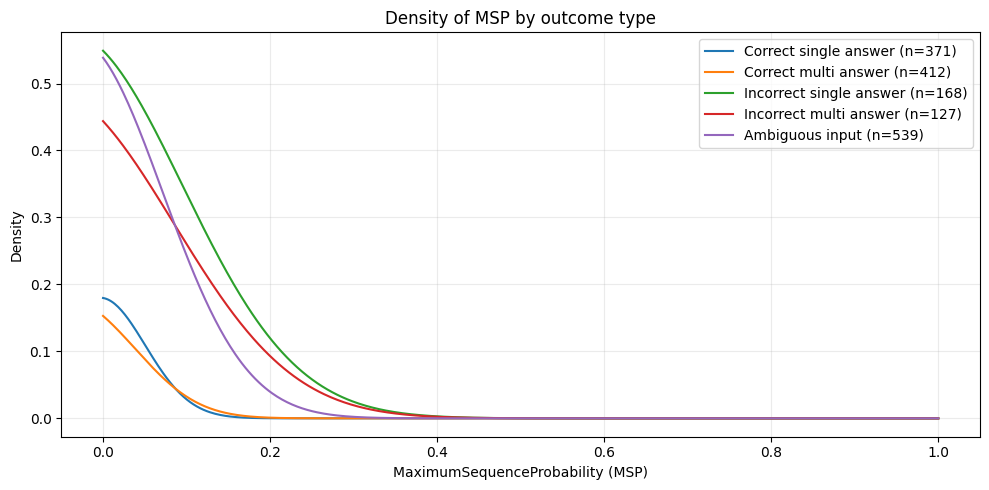

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
order = [
    "Correct single answer",
    "Correct multi answer",
    "Incorrect single answer",
    "Incorrect multi answer",
    "Ambiguous input",
]

x_grid = np.linspace(0, 1, 500)  # adjust if MSP range differs

plt.figure(figsize=(10, 5))

for bucket in order:
    vals = df_plot.loc[df_plot["bucket"] == bucket, "msp"].dropna().to_numpy()
    if len(vals) < 5:
        continue  # KDE unstable for tiny samples

    kde = gaussian_kde(vals)
    plt.plot(x_grid, kde(x_grid), label=f"{bucket} (n={len(vals)})")

plt.xlabel("MaximumSequenceProbability (MSP)")
plt.ylabel("Density")
plt.title("Density of MSP by outcome type")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
summary = (
    df_plot
    .groupby("bucket")["msp"]
    .agg(
        n="count",
        mean="mean",
        std="std",
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        min="min",
        max="max",
    )
    .reindex(order)
)

summary


,n,mean,std,median,q25,q75,min,max
bucket,,,,,,,,
Correct single answer,371,-0.945008,0.174833,-1.00,-1.00,-0.9500,-1.0,-0.0
Correct multi answer,412,-0.888694,0.226196,-0.95,-1.00,-0.9500,-1.0,-0.0
Incorrect single answer,168,-0.770774,0.367833,-0.95,-0.95,-0.8875,-1.0,-0.0
Incorrect multi answer,127,-0.742612,0.345089,-0.95,-0.95,-0.7500,-1.0,-0.0
Ambiguous input,539,-0.798128,0.334481,-0.95,-0.99,-0.8000,-1.0,-0.0


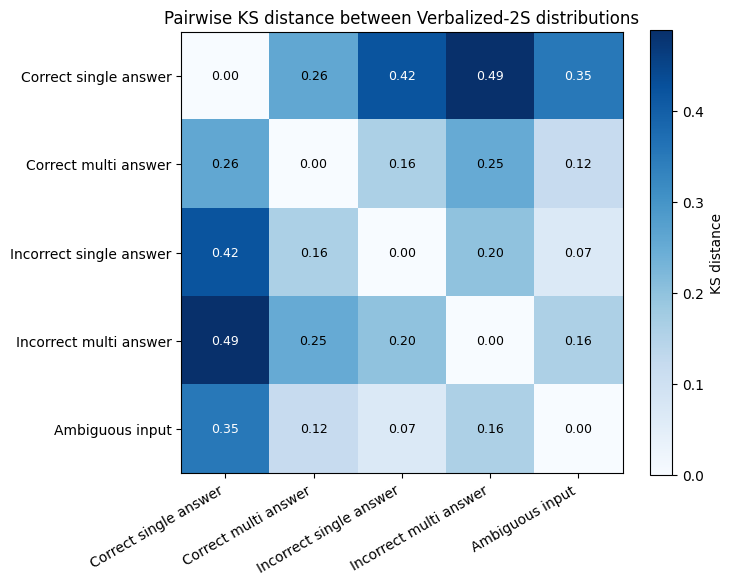

In [31]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp, wasserstein_distance

buckets = [
    "Correct single answer",
    "Correct multi answer",
    "Incorrect single answer",
    "Incorrect multi answer",
    "Ambiguous input",
]

# Collect MSP arrays
vals = {
    b: df_plot.loc[df_plot["bucket"] == b, "msp"].dropna().to_numpy()
    for b in buckets
}

# KS distance matrix
ks_mat = pd.DataFrame(index=buckets, columns=buckets, dtype=float)
wd_mat = pd.DataFrame(index=buckets, columns=buckets, dtype=float)

for b1 in buckets:
    for b2 in buckets:
        ks_mat.loc[b1, b2] = ks_2samp(vals[b1], vals[b2]).statistic
        wd_mat.loc[b1, b2] = wasserstein_distance(vals[b1], vals[b2])

import matplotlib.pyplot as plt
plt.figure(figsize=(7.5, 6))

im = plt.imshow(ks_mat.values, cmap="Blues", interpolation="nearest")
plt.colorbar(im, label="KS distance")

plt.xticks(range(len(buckets)), buckets, rotation=30, ha="right")
plt.yticks(range(len(buckets)), buckets)

# Add numeric annotations
for i in range(len(buckets)):
    for j in range(len(buckets)):
        val = ks_mat.values[i, j]
        plt.text(
            j, i, f"{val:.2f}",
            ha="center", va="center",
            color="white" if val > ks_mat.values.max() * 0.6 else "black",
            fontsize=9,
        )

plt.title("Pairwise KS distance between Verbalized-2S distributions")
plt.tight_layout()
plt.show()


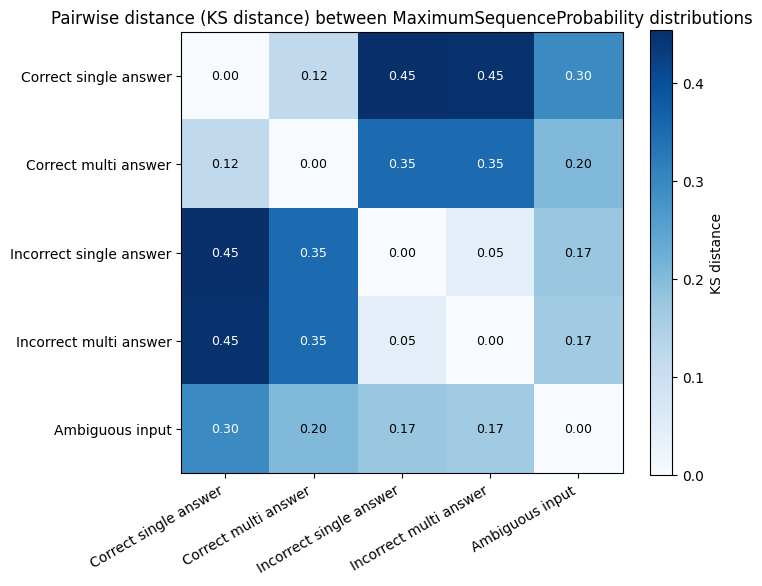

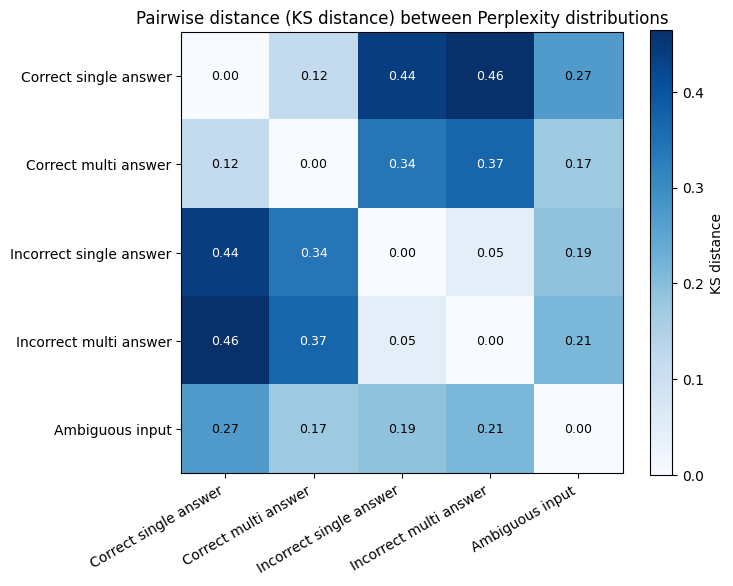

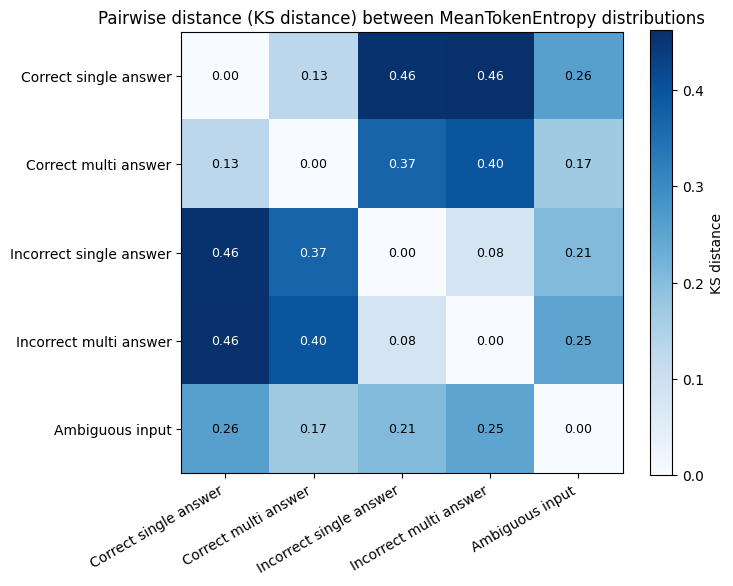

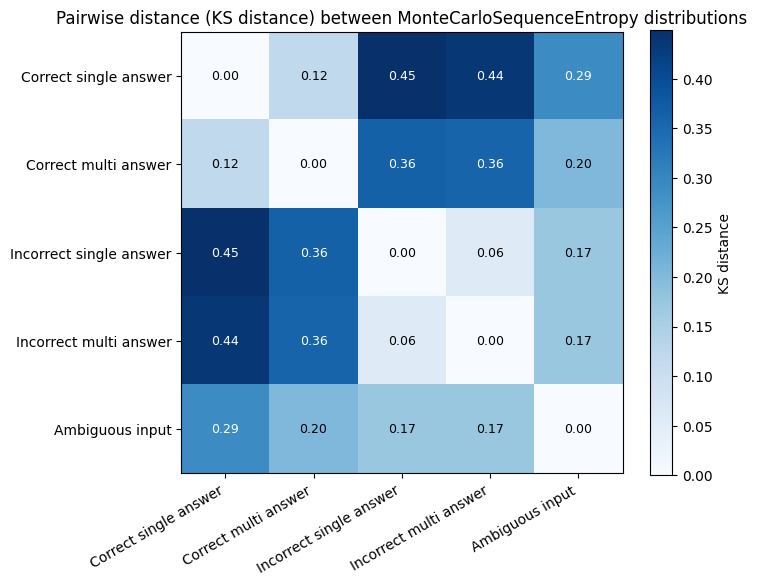

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, wasserstein_distance

def plot_pairwise_distance_heatmap(
    managers,
    method_name,
    *,
    buckets_order=None,
    distance="ks",          # "ks" or "wasserstein"
    cmap="Blues",
    figsize=(7.5, 6),
    title_prefix="Pairwise distance",
    annotate=True,
):
    """
    Build df from managers, bucket by scenario + decision, then plot pairwise distance heatmap
    for the distributions of estimations[('sequence', method_name)].

    Parameters
    ----------
    managers : dict[str, manager]
        e.g. {"Ambiguous input": man_ambi, "Multi-answer": man_multi, "Single answer": man_single}
    method_name : str
        The second item in estimations[('sequence', method_name)], e.g. "UEVerbalized2S"
    buckets_order : list[str] | None
        Order of buckets on axes. If None, uses default.
    distance : str
        "ks" for KS statistic, or "wasserstein" for 1D Wasserstein distance.
    """
    if buckets_order is None:
        buckets_order = [
            "Correct single answer",
            "Correct multi answer",
            "Incorrect single answer",
            "Incorrect multi answer",
            "Ambiguous input",
        ]

    msp_key = ("sequence", method_name)
    decision_key = ("sequence", "decision")

    # --- build tidy df ---
    rows = []
    for scenario_name, man in managers.items():
        # method values
        msp = np.asarray(man.estimations[msp_key], dtype=float)

        # decision (may not exist)
        try:
            decision = np.asarray(man.gen_metrics[decision_key], dtype=float)
        except Exception:
            decision = np.full_like(msp, np.nan, dtype=float)

        n = min(len(msp), len(decision))
        for i in range(n):
            rows.append(
                {
                    "scenario_name": scenario_name,
                    "idx": i,
                    "msp": msp[i],
                    "decision": decision[i],
                }
            )

    df = pd.DataFrame(rows)

    # --- bucket assignment ---
    def assign_bucket(row):
        if row["scenario_name"] == "Ambiguous input":
            return "Ambiguous input"

        if row["scenario_name"] == "Single answer":
            if row["decision"] == 1:
                return "Correct single answer"
            elif row["decision"] == 0:
                return "Incorrect single answer"
            return "Single answer (unknown)"

        if row["scenario_name"] == "Multi-answer":
            if row["decision"] == 1:
                return "Correct multi answer"
            elif row["decision"] == 0:
                return "Incorrect multi answer"
            return "Multi answer (unknown)"

        return "Other"

    df["bucket"] = df.apply(assign_bucket, axis=1)
    df_plot = df[df["bucket"].isin(buckets_order)].copy()

    # --- collect arrays per bucket ---
    vals = {
        b: df_plot.loc[df_plot["bucket"] == b, "msp"].dropna().to_numpy()
        for b in buckets_order
    }

    # --- compute distance matrix ---
    dist_mat = pd.DataFrame(index=buckets_order, columns=buckets_order, dtype=float)

    for b1 in buckets_order:
        for b2 in buckets_order:
            x, y = vals[b1], vals[b2]
            if len(x) == 0 or len(y) == 0:
                dist_mat.loc[b1, b2] = np.nan
                continue

            if distance.lower() == "ks":
                dist_mat.loc[b1, b2] = ks_2samp(x, y).statistic
            elif distance.lower() in ["wasserstein", "wd", "emd"]:
                dist_mat.loc[b1, b2] = wasserstein_distance(x, y)
            else:
                raise ValueError("distance must be 'ks' or 'wasserstein'")

    # --- plot heatmap ---
    plt.figure(figsize=figsize)
    im = plt.imshow(dist_mat.values.astype(float), cmap=cmap, interpolation="nearest")
    label = "KS distance" if distance.lower() == "ks" else "Wasserstein distance"
    plt.colorbar(im, label=label)

    plt.xticks(range(len(buckets_order)), buckets_order, rotation=30, ha="right")
    plt.yticks(range(len(buckets_order)), buckets_order)

    if annotate:
        vmax = np.nanmax(dist_mat.values.astype(float))
        for i in range(len(buckets_order)):
            for j in range(len(buckets_order)):
                v = dist_mat.values[i, j]
                if np.isnan(v):
                    txt = "NaN"
                    color = "black"
                else:
                    txt = f"{v:.2f}"
                    color = "white" if vmax and v > vmax * 0.6 else "black"
                plt.text(j, i, txt, ha="center", va="center", color=color, fontsize=9)

    plt.title(f"{title_prefix} ({label}) between {method_name} distributions")
    plt.tight_layout()
    plt.show()

    return dist_mat, df_plot

# KS heatmap

methods = ['MaximumSequenceProbability', 'Perplexity', 'MeanTokenEntropy', 'MonteCarloSequenceEntropy']
for method in methods:
    plot_pairwise_distance_heatmap(managers, method, distance="ks")

# Wasserstein heatmap
# plot_pairwise_distance_heatmap(managers, "UEVerbalized2S", distance="wasserstein")


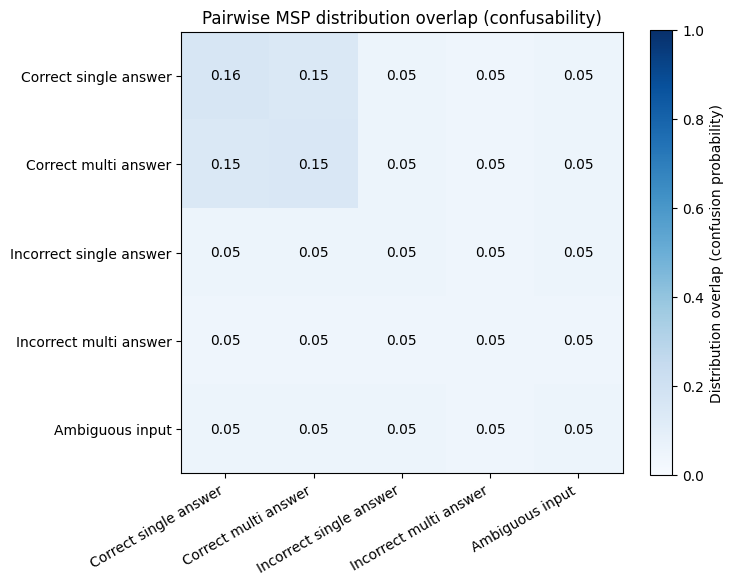

In [8]:
import numpy as np
from scipy.stats import gaussian_kde

def overlap_coefficient(x, y, grid=None):
    if grid is None:
        grid = np.linspace(0, 1, 500)

    kde_x = gaussian_kde(x)
    kde_y = gaussian_kde(y)

    px = kde_x(grid)
    py = kde_y(grid)

    return np.trapz(np.minimum(px, py), grid)

overlap_mat = pd.DataFrame(index=buckets, columns=buckets, dtype=float)

for b1 in buckets:
    for b2 in buckets:
        overlap_mat.loc[b1, b2] = overlap_coefficient(vals[b1], vals[b2])
plt.figure(figsize=(7.5, 6))
im = plt.imshow(overlap_mat.values, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, label="Distribution overlap (confusion probability)")

plt.xticks(range(len(buckets)), buckets, rotation=30, ha="right")
plt.yticks(range(len(buckets)), buckets)

for i in range(len(buckets)):
    for j in range(len(buckets)):
        plt.text(j, i, f"{overlap_mat.values[i,j]:.2f}",
                 ha="center", va="center",
                 color="white" if overlap_mat.values[i,j] > 0.6 else "black")

plt.title("Pairwise MSP distribution overlap (confusability)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_4154040/4044632874.py:33: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  auc_sym = auc_mat.applymap(lambda x: max(x, 1 - x))  # in [0.5, 1]


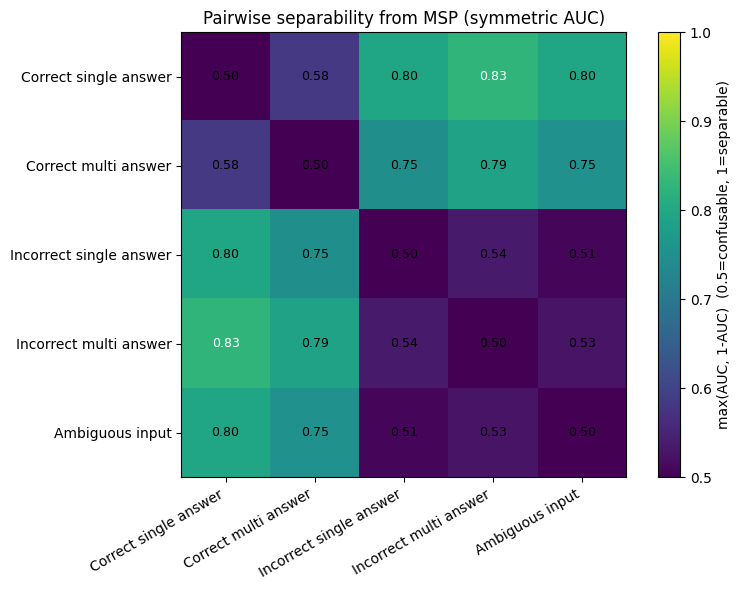

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

buckets = [
    "Correct single answer",
    "Correct multi answer",
    "Incorrect single answer",
    "Incorrect multi answer",
    "Ambiguous input",
]

vals = {
    b: df_plot.loc[df_plot["bucket"] == b, "msp"].dropna().to_numpy()
    for b in buckets
}

def pairwise_auc(a, b):
    # AUC where b is positive class (label=1), a is negative (label=0)
    y = np.r_[np.zeros(len(a)), np.ones(len(b))]
    scores = np.r_[a, b]
    return roc_auc_score(y, scores)

auc_mat = pd.DataFrame(index=buckets, columns=buckets, dtype=float)

for i, bi in enumerate(buckets):
    for j, bj in enumerate(buckets):
        if bi == bj:
            auc_mat.loc[bi, bj] = 0.5
        else:
            auc_mat.loc[bi, bj] = pairwise_auc(vals[bi], vals[bj])
auc_sym = auc_mat.applymap(lambda x: max(x, 1 - x))  # in [0.5, 1]

plt.figure(figsize=(8, 6))
im = plt.imshow(auc_sym.values, cmap="viridis", vmin=0.5, vmax=1.0, interpolation="nearest")
plt.colorbar(im, label="max(AUC, 1-AUC)  (0.5=confusable, 1=separable)")

plt.xticks(range(len(buckets)), buckets, rotation=30, ha="right")
plt.yticks(range(len(buckets)), buckets)

for r in range(len(buckets)):
    for c in range(len(buckets)):
        v = auc_sym.values[r, c]
        plt.text(
            c, r, f"{v:.2f}",
            ha="center", va="center",
            color="white" if v > 0.80 else "black",
            fontsize=9,
        )

plt.title("Pairwise separability from MSP (symmetric AUC)")
plt.tight_layout()
plt.show()



In [15]:
from scipy.stats import ks_2samp

baseline = "Correct single answer"
base = df_plot.loc[df_plot["bucket"] == baseline, "msp"].dropna().to_numpy()

for bucket in order:
    if bucket == baseline:
        continue
    vals = df_plot.loc[df_plot["bucket"] == bucket, "msp"].dropna().to_numpy()
    if len(vals) == 0:
        continue
    ks = ks_2samp(base, vals).statistic
    print(f"KS({baseline} vs {bucket}) = {ks:.3f}")


KS(Correct single answer vs Correct multi answer) = 0.157
KS(Correct single answer vs Incorrect single answer) = 0.461
KS(Correct single answer vs Incorrect multi answer) = 0.530
KS(Correct single answer vs Ambiguous input) = 0.472


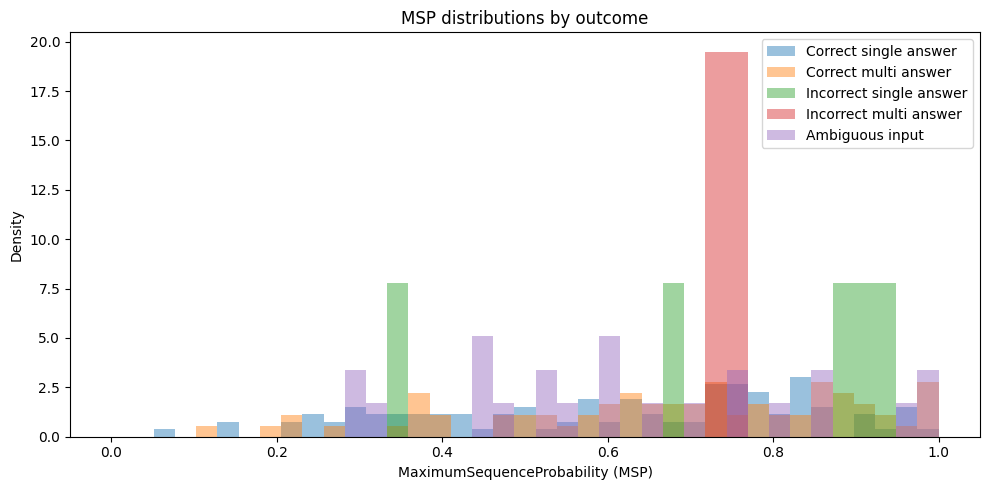

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))

bins = np.linspace(0, 1, 40)  # MSP is usually in [0,1]

for bucket in [
    "Correct single answer",
    "Correct multi answer",
    "Incorrect single answer",
    "Incorrect multi answer",
    "Ambiguous input",
]:
    vals = df_plot.loc[df_plot["bucket"] == bucket, "msp"].dropna().values
    if len(vals) == 0:
        continue
    plt.hist(
        vals,
        bins=bins,
        density=True,      # normalize
        alpha=0.45,
        label=bucket,
        histtype="stepfilled",
    )

plt.xlabel("MaximumSequenceProbability (MSP)")
plt.ylabel("Density")
plt.title("MSP distributions by outcome")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
from collections import defaultdict
from types import SimpleNamespace

# managers = { 'Ambiguous input': man_ambi, 'Multi-answer': man_multi, 'Single answer': man_single }

# create an empty combined manager-like object
combined = SimpleNamespace(
    stats={},
    estimations=defaultdict(list),
    metrics=defaultdict(list),
    gen_metrics=defaultdict(list),
)

for scenario_name, man in managers.items():
    # ---- stats ----
    for key, value in man.stats.items():
        if isinstance(value, list):
            
            # per-generation list -> concatenate
            combined.stats.setdefault(key, []).extend(value)
        else:
            # scalar/statistic -> store per scenario
            combined.stats.setdefault(key, {})[scenario_name] = value

    # add scenario label per generation (based on labels length)
    n = len(man.stats["labels"])
    combined.stats.setdefault("scenario", []).extend([scenario_name] * n)

    # ---- estimations ----
    for key, values in man.estimations.items():         # key is ('sequence', method)
        combined.estimations[key].extend(values)

    # ---- metrics ----
    for key, value in man.metrics.items():
        if isinstance(value, list):
            combined.metrics[key].extend(value)
        else:
            combined.metrics.setdefault(key, {})[scenario_name] = value

    # ---- gen_metrics ----
    for key, value in man.gen_metrics.items():
        if isinstance(value, list):
            combined.gen_metrics[key].extend(value)
        else:
            combined.gen_metrics.setdefault(key, {})[scenario_name] = value


In [ ]:
from collections import defaultdict
from types import SimpleNamespace

managers_single_ambi = { 'Ambiguous input': man_ambi, 'Single answer': man_single }

# create an empty combined manager-like object
single_ambi = SimpleNamespace(
    stats={},
    estimations=defaultdict(list),
    metrics=defaultdict(list),
    gen_metrics=defaultdict(list),
)

for scenario_name, man in managers_single_ambi.items():
    # ---- stats ----
    for key, value in man.stats.items():
        if isinstance(value, list):
            
            # per-generation list -> concatenate
            single_ambi.stats.setdefault(key, []).extend(value)
        else:
            # scalar/statistic -> store per scenario
            single_ambi.stats.setdefault(key, {})[scenario_name] = value

    # add scenario label per generation (based on labels length)
    n = len(man.stats["labels"])
    single_ambi.stats.setdefault("scenario", []).extend([scenario_name] * n)

    # ---- estimations ----
    for key, values in man.estimations.items():         # key is ('sequence', method)
        single_ambi.estimations[key].extend(values)

    # ---- metrics ----
    for key, value in man.metrics.items():
        if isinstance(value, list):
            single_ambi.metrics[key].extend(value)
        else:
            single_ambi.metrics.setdefault(key, {})[scenario_name] = value

    # ---- gen_metrics ----
    for key, value in man.gen_metrics.items():
        if isinstance(value, list):
            single_ambi.gen_metrics[key].extend(value)
        else:
            single_ambi.gen_metrics.setdefault(key, {})[scenario_name] = value


In [ ]:
import copy

order = ['Ambiguous input', 'Multi-answer', 'Single answer']

base_name = order[0]
combined = copy.deepcopy(managers[base_name])  # start from first manager

n_base = len(combined.stats["labels"])
combined.stats["scenario"] = [base_name] * n_base  # per-generation scenario label
def ensure_scenario_dict(stats_or_metrics, key, scenario_name):
    """Turn a scalar value into {scenario_name: value} if needed."""
    val = stats_or_metrics.get(key)
    if isinstance(val, dict):
        return
    stats_or_metrics[key] = {scenario_name: val}

for k, v in list(combined.stats.items()):
    if not isinstance(v, list) and k != "scenario":
        ensure_scenario_dict(combined.stats, k, base_name)

for k, v in list(combined.metrics.items()):
    if not isinstance(v, list):
        ensure_scenario_dict(combined.metrics, k, base_name)

for k, v in list(combined.gen_metrics.items()):
    if not isinstance(v, list):
        ensure_scenario_dict(combined.gen_metrics, k, base_name)

def append_manager(combined, other, other_name):
    # --- stats ---
    n_other = len(other.stats["labels"])
    combined.stats["scenario"].extend([other_name] * n_other)

    for key, val in other.stats.items():
        if key == "scenario":
            continue
        if isinstance(val, list):
            combined.stats.setdefault(key, [])
            combined.stats[key].extend(val)
        else:
            # per-scenario scalar
            ensure_scenario_dict(combined.stats, key, other_name)
            combined.stats[key][other_name] = val

    # --- estimations ---
    for key, vals in other.estimations.items():  # key is ('sequence', method)
        combined.estimations.setdefault(key, [])
        combined.estimations[key].extend(vals)

    # --- metrics ---
    for key, val in other.metrics.items():
        if isinstance(val, list):
            combined.metrics.setdefault(key, [])
            combined.metrics[key].extend(val)
        else:
            ensure_scenario_dict(combined.metrics, key, other_name)
            combined.metrics[key][other_name] = val

    # --- gen_metrics ---
    for key, val in other.gen_metrics.items():
        if isinstance(val, list):
            combined.gen_metrics.setdefault(key, [])
            combined.gen_metrics[key].extend(val)
        else:
            ensure_scenario_dict(combined.gen_metrics, key, other_name)
            combined.gen_metrics[key][other_name] = val
for name in order[1:]:
    append_manager(combined, managers[name], name)


In [ ]:
import copy

order = ['Ambiguous input','Single answer']

base_name = order[0]
single_ambi = copy.deepcopy(managers_single_ambi[base_name])  # start from first manager

n_base = len(single_ambi.stats["labels"])
single_ambi.stats["scenario"] = [base_name] * n_base  # per-generation scenario label
def ensure_scenario_dict(stats_or_metrics, key, scenario_name):
    """Turn a scalar value into {scenario_name: value} if needed."""
    val = stats_or_metrics.get(key)
    if isinstance(val, dict):
        return
    stats_or_metrics[key] = {scenario_name: val}

for k, v in list(single_ambi.stats.items()):
    if not isinstance(v, list) and k != "scenario":
        ensure_scenario_dict(single_ambi.stats, k, base_name)

for k, v in list(single_ambi.metrics.items()):
    if not isinstance(v, list):
        ensure_scenario_dict(single_ambi.metrics, k, base_name)

for k, v in list(single_ambi.gen_metrics.items()):
    if not isinstance(v, list):
        ensure_scenario_dict(single_ambi.gen_metrics, k, base_name)

def append_manager(single_ambi, other, other_name):
    # --- stats ---
    n_other = len(other.stats["labels"])
    single_ambi.stats["scenario"].extend([other_name] * n_other)

    for key, val in other.stats.items():
        if key == "scenario":
            continue
        if isinstance(val, list):
            single_ambi.stats.setdefault(key, [])
            single_ambi.stats[key].extend(val)
        else:
            # per-scenario scalar
            ensure_scenario_dict(combined.stats, key, other_name)
            single_ambi.stats[key][other_name] = val

    # --- estimations ---
    for key, vals in other.estimations.items():  # key is ('sequence', method)
        single_ambi.estimations.setdefault(key, [])
        single_ambi.estimations[key].extend(vals)

    # --- metrics ---
    # for key, val in other.metrics.items():
    #     if isinstance(val, list):
    #         single_ambi.metrics.setdefault(key, [])
    #         single_ambi.metrics[key].extend(val)
    #     else:
    #         ensure_scenario_dict(combined.metrics, key, other_name)
    #         single_ambi.metrics[key][other_name] = val

    # --- gen_metrics ---
    for key, val in other.gen_metrics.items():
        if isinstance(val, list):
            single_ambi.gen_metrics.setdefault(key, [])
            single_ambi.gen_metrics[key].extend(val)
        else:
            ensure_scenario_dict(combined.gen_metrics, key, other_name)
            single_ambi.gen_metrics[key][other_name] = val
for name in order[1:]:
    append_manager(single_ambi, managers_single_ambi[name], name)


In [ ]:
from lm_polygraph.ue_metrics import PredictionRejectionArea

ue_metrics = [PredictionRejectionArea(max_rejection=0.5), PredictionRejectionArea(), PredictionRejectionArea(max_rejection=0.75)]
combined.ue_metrics =ue_metrics
combined.eval_ue()

We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2

In [ ]:
from lm_polygraph.ue_metrics import PredictionRejectionArea

ue_metrics = [PredictionRejectionArea(max_rejection=0.5), PredictionRejectionArea(), PredictionRejectionArea(max_rejection=0.75)]
single_ambi.ue_metrics =ue_metrics
single_ambi.eval_ue()

We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2

In [ ]:
combined.metrics[('sequence', 'MaximumSequenceProbability', 'decision', 'prr_0.5_normalized')]

0.44019144174197156

In [ ]:
ue_metrics = [PredictionRejectionArea(max_rejection=0.5), PredictionRejectionArea(), PredictionRejectionArea(max_rejection=0.75)]
man_single.ue_metrics =ue_metrics
man_single.eval_ue()

man_multi.ue_metrics =ue_metrics
man_multi.eval_ue()

man_ambi.ue_metrics =ue_metrics
man_ambi.eval_ue()

We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2 generation metric.
We got 207 nans in Rouge_rouge2

In [ ]:
import pandas as pd

def extract_prr(metrics, max_rejection = None):
    rows = []
    for key, value in metrics.items():
        if max_rejection:
            if (
                isinstance(key, tuple)
                and len(key) == 4
                and key[0] == "sequence"
                and key[2] == "decision"
                and key[3] == f"prr_{max_rejection}_normalized"
            ):
                method = key[1]
                rows.append({"method": method, "prr": float(value)})
        else:
            if (
                isinstance(key, tuple)
                and len(key) == 4
                and key[0] == "sequence"
                and key[2] == "decision"
                and key[3] == "prr_normalized"
            ):
                method = key[1]
                rows.append({"method": method, "prr": float(value)})

    df = pd.DataFrame(rows).set_index("method")
    return df["prr"]

mrs = [0.5 , 0.75, None]

for mr in mrs:
    s_combined = extract_prr(combined.metrics, max_rejection=mr).rename("combined")
    s_multi    = extract_prr(man_multi.metrics, max_rejection=mr).rename("multi")
    s_single   = extract_prr(man_single.metrics, max_rejection=mr).rename("single")
    s_single_ambi   = extract_prr(single_ambi.metrics, max_rejection=mr).rename("single_ambi")

    df = pd.concat([
    s_single.rename("prr").to_frame().assign(type="single"),
    s_multi.rename("prr").to_frame().assign(type="multi"),
    s_combined.rename("prr").to_frame().assign(type="combined"),
    s_single_ambi.rename("prr").to_frame().assign(type="single_ambi")
], axis=0)

    # df = df.reset_index().rename(columns={"index": "method"})

    filename = f"results/{model}_prr_results_{mr}_reject_with_NLI_and_verb.csv"
    df["method"] = df.index
    df.to_csv(filename, index=False)
    print("Saved to:", filename)


Saved to: results/llama8bit_prr_results_0.5_reject_with_NLI_and_verb.csv
Saved to: results/llama8bit_prr_results_0.75_reject_with_NLI_and_verb.csv
Saved to: results/llama8bit_prr_results_None_reject_with_NLI_and_verb.csv


In [51]:
import pandas as pd

# ---------- 1. Load and pivot each model ----------

def load_model_table(csv_path: str, model_label: str):
    """
    csv_path: path to CSV with columns [method, prr, type]
    model_label: label used in column MultiIndex (e.g. 'llama', 'mistral')
    """
    df = pd.read_csv(csv_path)  # expects: method, prr, type
    wide = df.pivot(index="method", columns="type", values="prr")

    # enforce column order: single, multi, combined
    wide = wide[["single", "multi", "combined"]]

    # MultiIndex columns: (model_label, type)
    wide.columns = pd.MultiIndex.from_product([[model_label],
                                               ["single", "multi", "combined"]])
    return wide

# Example usage: replace paths + labels as needed
t_llama   = load_model_table("results/llama8bit_prr_results_None_reject.csv",   "llama8bit")
t_gemma = load_model_table("results/gemma12bit_prr_results_None_reject.csv", "gemma12bit")
t_qwen = load_model_table("results/qwen3_prr_results_None_reject_new.csv", "qwen")
# ---------- 2. Combine side-by-side on 'method' ----------

combined = pd.concat([t_llama, t_gemma, t_qwen], axis=1)

# Optional: enforce metric order if you have one
metric_order = [
    "MaximumSequenceProbability",
    "Perplexity",
    "MeanTokenEntropy",
    "MeanPointwiseMutualInformation",
    # "MeanConditionalPointwiseMutualInformation",
    "MonteCarloSequenceEntropy",
    "MonteCarloNormalizedSequenceEntropy",
    # "ToeknSAR",

    "Consistency",
    "NumSemSets",
    "EigValLaplacian_NLI_score_entail",
    # "EigValLaplacian_NLI_score_contra",
    "EigValLaplacian_Jaccard_score",
    "DegMat_NLI_score_entail",
    # "DegMat_NLI_score_contra",
    "Eccentricity_NLI_score_entail",
    # "Eccentricity_NLI_score_contra",

    "SemanticEntropy",
    "LUQ",
    "SAR",
    "SemanticDensity",
    "CocoaMSP",
    "CocoaPPL",
    "CocoaMTE",

    "CCP",
    # "TokenSAR",
    "PTrue"
]

metric_pretty_name = {
    "MaximumSequenceProbability":"SP",
    "Perplexity" : "PPL",
    "MeanTokenEntropy" : "MTE",
    "MeanPointwiseMutualInformation" : "MPMI",
    "MeanConditionalPointwiseMutualInformation" :"MCPMI",
    "MonteCarloSequenceEntropy" :"MCSE",
    "MonteCarloNormalizedSequenceEntropy" : "MCNSE",
    "ToeknSAR":"TokenSAR",

    "NumSemSets": "NumSemSets",
    "EigValLaplacian_NLI_score_entail":"$\\text{EigValLaplacian}_{entail}$",
    "EigValLaplacian_NLI_score_contra":"$\\text{EigValLaplacian}_{contra}$",
    "EigValLaplacian_Jaccard_score":"$\\text{EigValLaplacian}_{Jaccard}$",
    "DegMat_NLI_score_entail":"$\\text{DegMat}_{entail}$",
    "DegMat_NLI_score_contra":"$\\text{DegMat}_{contra}$",
    "Eccentricity_NLI_score_entail":"$\\text{Eccentricity}_{entail}$",
    "Eccentricity_NLI_score_contra":"$\\text{Eccentricity}_{contra}$",

    "Consistency":"Consistency",
    "SemanticEntropy":"Semantic Entropy",
    "LUQ":"LUQ",
    "SAR":"SAR",
    "SemanticDensity":"Semantic Density",
    "CocoaMSP":"CocoaMSP",
    "CocoaPPL":"CocoaPPL",
    "CocoaMTE":"CocoaMTE",

    "CCP":"CCP",
    "PTrue":"P(True)",
}

combined = combined.reindex(metric_order).dropna(how="all")

# models + types in order
models = ["llama8bit", "gemma12bit", "qwen"]
types = ["single", "multi", "combined"]


# ---------- 3. (Optional) escape LaTeX specials in metric names ----------

def latex_escape(s: str) -> str:
    return (
        s.replace("\\", r"\textbackslash{}")
         .replace("_", r"\_")
         .replace("%", r"\%")
         .replace("&", r"\&")
         .replace("#", r"\#")
         .replace("{", r"\{")
         .replace("}", r"\}")
    )


# ---------- 4. Format best (bold) and second-best (underline) per column ----------

formatted = combined.copy().astype(object)  # make room for strings

for col in formatted.columns:  # col is like ('llama8bit', 'single')
    s = combined[col]
    s_nonan = s.dropna()

    if len(s_nonan) == 0:
        continue

    best_idx = s_nonan.idxmax()
    second_idx = s_nonan.drop(best_idx).idxmax() if len(s_nonan) > 1 else None

    for idx in combined.index:
        val = combined.loc[idx, col]
        if pd.isna(val):
            formatted.loc[idx, col] = ""
            continue

        txt = f"{val:.3f}"
        if idx == best_idx:
            formatted.loc[idx, col] = rf"\textbf{{{txt}}}"
        elif second_idx is not None and idx == second_idx:
            formatted.loc[idx, col] = rf"\underline{{{txt}}}"
        else:
            formatted.loc[idx, col] = txt


# ---------- 5. Build LaTeX body rows safely (no brace issues) ----------

rows = []
for metric, row in formatted.iterrows():   # use formatted, not combined
    if pd.isna(row).all():
        continue
    metric_name =  metric_pretty_name[metric] # latex_escape(metric)
    cells = [metric_name]
    for m in models:
        for t in types:
            cell = row[(m, t)]
            cells.append("" if pd.isna(cell) else str(cell))
    rows.append(" & ".join(cells) + r" \\")
body = "\n".join(rows)


# ---------- 6. Build the LaTeX header with multicolumns per model ----------

# column spec: 1 metric column + 3 per model
colspec = "l" + "ccc" * len(models)

# model names in header
model_headers = {
    "llama8bit": "Llama-8b-it",
    "gemma12bit": "Gemma-12b-it",
    "qwen": "Qwen-14b-it"
}

header_line1_parts = [r"\textbf{Metric}"]
for m in models:
    model_tex = model_headers[m]
    part = f"\\multicolumn{{3}}{{c}}{{\\textbf{{{model_tex}}}}}"
    header_line1_parts.append(part)
header_line1 = " & ".join(header_line1_parts) + r" \\"

# cmidrule lines
cmidrules = []
col_start = 2  # first model block starts at column 2
for _ in models:
    col_end = col_start + 2
    cmidrules.append(f"\\cmidrule(lr){{{col_start}-{col_end}}}")
    col_start = col_end + 1
cmidrule_line = " ".join(cmidrules)

# second header line: metric column is empty, then types for each model
second_header_cells = [""]
for _ in models:
    second_header_cells.extend([
        r"\textbf{single}",
        r"\textbf{multi}",
        r"\textbf{combined}",
    ])
second_header_line = " & ".join(second_header_cells) + r" \\"


# ---------- 7. Put everything together ----------

latex_table = (
    f"\\begin{{tabular}}{{{colspec}}}\n"
    "\\toprule\n"
    + header_line1 + "\n"
    + cmidrule_line + "\n"
    + second_header_line + "\n"
    "\\midrule\n"
    + body + "\n"
    "\\bottomrule\n"
    "\\end{tabular}"
)

print(latex_table)


\begin{tabular}{lccccccccc}
\toprule
\textbf{Metric} & \multicolumn{3}{c}{\textbf{Llama-8b-it}} & \multicolumn{3}{c}{\textbf{Gemma-12b-it}} & \multicolumn{3}{c}{\textbf{Qwen-14b-it}} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7} \cmidrule(lr){8-10}
 & \textbf{single} & \textbf{multi} & \textbf{combined} & \textbf{single} & \textbf{multi} & \textbf{combined} & \textbf{single} & \textbf{multi} & \textbf{combined} \\
\midrule
SP & 0.692 & 0.688 & 0.578 & 0.643 & 0.513 & 0.396 & -0.075 & -0.079 & 0.297 \\
PPL & 0.617 & 0.557 & 0.516 & 0.625 & 0.494 & 0.369 & -0.075 & -0.079 & 0.297 \\
MTE & 0.665 & 0.634 & 0.580 & 0.654 & 0.517 & 0.382 & \underline{-0.060} & -0.085 & \textbf{0.302} \\
MPMI & 0.360 & 0.432 & 0.274 & 0.242 & 0.092 & 0.212 & -0.075 & -0.079 & 0.297 \\
MCSE & 0.693 & \textbf{0.721} & \textbf{0.598} & 0.659 & 0.520 & 0.406 & -0.075 & -0.079 & 0.297 \\
MCNSE & 0.619 & 0.539 & 0.509 & 0.627 & 0.491 & 0.372 & -0.075 & -0.079 & 0.297 \\
Consistency & 0.599 & 0.528 & 0.455 & 0.473 & 0.48

In [ ]:
import pandas as pd

# ---------- 1. Load and pivot each model ----------

def load_model_table(csv_path: str, model_label: str):
    """
    csv_path: path to CSV with columns [method, prr, type]
    model_label: label used in column MultiIndex (e.g. 'llama', 'mistral')
    """
    df = pd.read_csv(csv_path)  # expects: method, prr, type
    wide = df.pivot(index="method", columns="type", values="prr")

    # desired types, including single_ambi
    desired_types = ["single", "single_ambi", "multi", "combined"]
    # use reindex so it works even if some types are missing in this file
    wide = wide.reindex(columns=desired_types)

    # MultiIndex columns: (model_label, type)
    wide.columns = pd.MultiIndex.from_product(
        [[model_label], desired_types]
    )
    return wide

# Example usage: replace paths + labels as needed
t_llama = load_model_table("results/llama8bit_prr_results_0.75_reject_with_NLI_and_verb.csv", "llama8bit")
t_gemma = load_model_table("results/gemma12bit_prr_results_0.75_reject_with_NLI_and_verb.csv", "gemma12bit")
t_qwen  = load_model_table("results/qwen_prr_results_0.75_reject_with_NLI_and_verb.csv",      "qwen")

# ---------- 2. Combine side-by-side on 'method' ----------

combined = pd.concat([t_llama, t_gemma, t_qwen], axis=1)

# Optional: enforce metric order if you have one
metric_order = [
    "MaximumSequenceProbability",
    "Perplexity",
    "MeanTokenEntropy",
    "MeanPointwiseMutualInformation",
    # "MeanConditionalPointwiseMutualInformation",
    "MonteCarloSequenceEntropy",
    "MonteCarloNormalizedSequenceEntropy",
    # "ToeknSAR",

    "Consistency",
    "NLIConsistency",
    "NumSemSets",
    "EigValLaplacian_NLI_score_entail",
    # "EigValLaplacian_NLI_score_contra",
    "EigValLaplacian_Jaccard_score",
    "DegMat_NLI_score_entail",
    # "DegMat_NLI_score_contra",
    "Eccentricity_NLI_score_entail",
    # "Eccentricity_NLI_score_contra",

    "SemanticEntropy",
    "LUQ",
    "SAR",
    "SemanticDensity",
    "CocoaMSP",
    "CocoaPPL",
    "CocoaMTE",
    "NLICocoaMSP",
    "NLICocoaPPL",
    "NLICocoaMTE",

    # "CCP",
    # "TokenSAR",
    "PTrue",
    'UEVerbalized2S'
]

metric_pretty_name = {
    "MaximumSequenceProbability": "SP",
    "Perplexity": "PPL",
    "MeanTokenEntropy": "MTE",
    "MeanPointwiseMutualInformation": "MPMI",
    "MeanConditionalPointwiseMutualInformation": "MCPMI",
    "MonteCarloSequenceEntropy": "MCSE",
    "MonteCarloNormalizedSequenceEntropy": "MCNSE",
    "ToeknSAR": "TokenSAR",

    "NumSemSets": "NumSemSets",
    "EigValLaplacian_NLI_score_entail": r"$\text{EigValLaplacian}_{entail}$",
    "EigValLaplacian_NLI_score_contra": r"$\text{EigValLaplacian}_{contra}$",
    "EigValLaplacian_Jaccard_score": r"$\text{EigValLaplacian}_{Jaccard}$",
    "DegMat_NLI_score_entail": r"$\text{DegMat}_{entail}$",
    "DegMat_NLI_score_contra": r"$\text{DegMat}_{contra}$",
    "Eccentricity_NLI_score_entail": r"$\text{Eccentricity}_{entail}$",
    "Eccentricity_NLI_score_contra": r"$\text{Eccentricity}_{contra}$",

    "Consistency": "Consistency",
        "NLIConsistency": "NLI_ConsistencyNLI",
    "SemanticEntropy": "Semantic Entropy",
    "LUQ": "LUQ",
    "SAR": "SAR",
    "SemanticDensity": "Semantic Density",
    "CocoaMSP": "CocoaMSP",
    "CocoaPPL": "CocoaPPL",
    "CocoaMTE": "CocoaMTE",
    "NLICocoaMSP": "NLICocoaMSP",
    "NLICocoaPPL": "NLICocoaPPL",
    "NLICocoaMTE": "NLICocoaMTE",
    "UEVerbalized2S":"Verbalized2S",
    "CCP": "CCP",
    "PTrue": "P(True)",
}

combined = combined.reindex(metric_order).dropna(how="all")

# models + types in order
models = ["llama8bit", "gemma12bit", "qwen"]
types = ["single", "single_ambi", "multi", "combined"]


# ---------- 3. (Optional) escape LaTeX specials in metric names ----------

def latex_escape(s: str) -> str:
    return (
        s.replace("\\", r"\textbackslash{}")
         .replace("_", r"\_")
         .replace("%", r"\%")
         .replace("&", r"\&")
         .replace("#", r"\#")
         .replace("{", r"\{")
         .replace("}", r"\}")
    )


# ---------- 4. Format best (bold) and second-best (underline) per column ----------
# Also: if a model doesn't have a value for a type, show '---'.

formatted = combined.copy().astype(object)  # make room for strings

for col in formatted.columns:  # col is like ('llama8bit', 'single')
    s = combined[col]
    s_nonan = s.dropna()

    # No non-NaN values at all in this column → everything becomes '---'
    if len(s_nonan) == 0:
        for idx in combined.index:
            formatted.loc[idx, col] = r"---"
        continue

    best_idx = s_nonan.idxmax()
    second_idx = s_nonan.drop(best_idx).idxmax() if len(s_nonan) > 1 else None

    for idx in combined.index:
        val = combined.loc[idx, col]
        if pd.isna(val):
            # Missing in this model/type → '---'
            formatted.loc[idx, col] = r"---"
            continue

        txt = f"{val:.3f}"
        if idx == best_idx:
            formatted.loc[idx, col] = rf"\textbf{{{txt}}}"
        elif second_idx is not None and idx == second_idx:
            formatted.loc[idx, col] = rf"\underline{{{txt}}}"
        else:
            formatted.loc[idx, col] = txt


# ---------- 5. Build LaTeX body rows ----------

rows = []
for metric, row in formatted.iterrows():   # use formatted, not combined
    # skip rows that are entirely missing (shouldn't happen after dropna(how="all"))
    if all((str(x) == "nan" for x in row)):
        continue

    metric_name = metric_pretty_name[metric]
    cells = [metric_name]
    for m in models:
        for t in types:
            cell = row[(m, t)]
            cells.append(str(cell))
    rows.append(" & ".join(cells) + r" \\")
body = "\n".join(rows)


# ---------- 6. Build the LaTeX header with multicolumns per model ----------

# column spec: 1 metric column + 4 per model
colspec = "l" + "cccc" * len(models)

# model names in header
model_headers = {
    "llama8bit": "Llama-8b-it",
    "gemma12bit": "Gemma-12b-it",
    "qwen": "Qwen-14b-it"
}

header_line1_parts = [r"\textbf{Metric}"]
for m in models:
    model_tex = model_headers[m]
    part = f"\\multicolumn{{4}}{{c}}{{\\textbf{{{model_tex}}}}}"
    header_line1_parts.append(part)
header_line1 = " & ".join(header_line1_parts) + r" \\"

# cmidrule lines: 4 columns per model block
cmidrules = []
col_start = 2  # first model block starts at column 2
for _ in models:
    col_end = col_start + 3  # 4 columns total
    cmidrules.append(f"\\cmidrule(lr){{{col_start}-{col_end}}}")
    col_start = col_end + 1
cmidrule_line = " ".join(cmidrules)

# second header line: metric column is empty, then types for each model
second_header_cells = [""]
for _ in models:
    second_header_cells.extend([
        r"\textbf{single}",
        r"\textbf{ambi}",
        r"\textbf{multi}",
        r"\textbf{combined}",
    ])
second_header_line = " & ".join(second_header_cells) + r" \\"


# ---------- 7. Put everything together ----------

latex_table = (
    f"\\begin{{tabular}}{{{colspec}}}\n"
    "\\toprule\n"
    + header_line1 + "\n"
    + cmidrule_line + "\n"
    + second_header_line + "\n"
    "\\midrule\n"
    + body + "\n"
    "\\bottomrule\n"
    "\\end{tabular}"
)

print(latex_table)


\begin{tabular}{lcccccccccccc}
\toprule
\textbf{Metric} & \multicolumn{4}{c}{\textbf{Llama-8b-it}} & \multicolumn{4}{c}{\textbf{Gemma-12b-it}} & \multicolumn{4}{c}{\textbf{Qwen-14b-it}} \\
\cmidrule(lr){2-5} \cmidrule(lr){6-9} \cmidrule(lr){10-13}
 & \textbf{single} & \textbf{ambi} & \textbf{multi} & \textbf{combined} & \textbf{single} & \textbf{ambi} & \textbf{multi} & \textbf{combined} & \textbf{single} & \textbf{ambi} & \textbf{multi} & \textbf{combined} \\
\midrule
SP & 0.596 & 0.496 & 0.590 & 0.499 & 0.561 & 0.390 & 0.452 & 0.355 & 0.553 & 0.401 & 0.547 & 0.397 \\
PPL & 0.511 & 0.431 & 0.449 & 0.412 & 0.540 & 0.352 & 0.452 & 0.322 & 0.557 & 0.397 & 0.521 & 0.374 \\
MTE & 0.575 & 0.486 & 0.531 & 0.482 & 0.580 & 0.372 & 0.495 & 0.342 & 0.579 & \underline{0.427} & \textbf{0.563} & 0.409 \\
MPMI & 0.364 & 0.184 & 0.405 & 0.267 & 0.159 & 0.203 & 0.113 & 0.179 & -0.075 & 0.052 & -0.026 & 0.042 \\
MCSE & 0.601 & 0.509 & \textbf{0.649} & 0.537 & 0.584 & 0.409 & 0.462 & 0.371 & 0.534 & 0.3

In [ ]:
from lm_polygraph.utils import UEManager
from lm_polygraph.estimators.cocoa import Consistency
from IPython.display import display
import json
import numpy as np
import pandas as pd

# ── config ──────────────────────────────────────────────────────────────────
# model = 'llama_3.3_70b'
# base_path = 'results'
base_path = '/nfs-stor/statml/maiya/managers_source_ue/final'
model='gemma12bit'

base_path_labels = '/nfs-stor/statml/maiya/managers_source_ue'

# ── load ─────────────────────────────────────────────────────────────────────
man_single = UEManager.load(f'{base_path}/single_{model}_no_embeddings.man')
man_multi  = UEManager.load(f'{base_path}/multi_{model}_no_embeddings.man')
man_ambi   = UEManager.load(f'{base_path}/ambi_{model}_no_embeddings.man')

managers = {
    'Ambiguous input': man_ambi,
    'Multi-answer':    man_multi,
    'Single answer':   man_single,
}

label_files = {
    'Ambiguous input': f"{base_path_labels}/annotations_ambi_{model}.jsonl",
    'Multi-answer':    f"{base_path_labels}/annotations_multi_{model}.jsonl",
    'Single answer':   f"{base_path_labels}/annotations_single_{model}.jsonl",
}

# ── enrich ───────────────────────────────────────────────────────────────────
def load_labels(path):
    with open(path) as f:
        return [json.loads(line)["label"] for line in f]

def compute_decision_metric(manager, scenario):
    labels = manager.stats["labels"]
    decisions = [
        1 if label == "correct" or (scenario == 'Ambiguous input' and label == 'clarification')
        else 0
        for label in labels
    ]
    manager.gen_metrics[('sequence', 'decision')] = decisions

for scenario, man in managers.items():
    man.stats["labels"] = load_labels(label_files[scenario])
    compute_decision_metric(man, scenario)

estimator = Consistency()
for scenario, man in managers.items():
    man.estimations[('sequence', str(estimator))] = list(estimator(man.stats))
    man.estimations[('sequence', 'UEVerbalized2S')] = [
        -x for x in man.estimations[('sequence', 'Verbalized2S')]
    ]

# ── table ─────────────────────────────────────────────────────────────────────
def group_stats(man):
    decisions = np.array(man.gen_metrics[('sequence', 'decision')])
    rows = {}
    for key, values in man.estimations.items():
        if key[0] != 'sequence':
            continue
        method = key[1]
        vals = np.array(values, dtype=float)
        for dec in (0, 1):
            mask = decisions == dec
            subset = vals[mask]
            rows.setdefault(method, {})[dec] = (
                (np.mean(subset), np.std(subset)) if len(subset) > 0 else (float('nan'), float('nan'))
            )
    return rows

# collect all method names across all managers
all_methods = sorted(set(
    key[1]
    for man in managers.values()
    for key in man.estimations
    if key[0] == 'sequence'
))

# build multi-level column DataFrame
scenario_order = ['Single answer', 'Multi-answer', 'Ambiguous input']
scenario_decs = {
    'Single answer':   (0, 1),
    'Multi-answer':    (0, 1),
    'Ambiguous input': (0,),
}
col_tuples = [(s, f'dec={d}') for s in scenario_order for d in scenario_decs[s]]
columns = pd.MultiIndex.from_tuples(col_tuples)

rows = []
for method in all_methods:
    row = []
    for scenario in scenario_order:
        man = managers[scenario]
        stats = group_stats(man)
        for dec in scenario_decs[scenario]:
            if method in stats and dec in stats[method]:
                mean, std = stats[method][dec]
                row.append(f"{mean:.3f} ± {std:.3f}")
            else:
                row.append("—")
    rows.append(row)

df = pd.DataFrame(rows, index=all_methods, columns=columns)
df.index.name = "Method"

display(df)
